# 02 — Energy Mix EDA / Анализ топливного баланса

## What this notebook does / Что в этом notebook'е

**EN.** Quantify the structural composition of Uzbekistan's power-generation mix from 1990 to 2024 and benchmark it against the four other Central Asia countries (Kazakhstan, Kyrgyzstan, Tajikistan, Turkmenistan). The output is a defensible answer to: *what is the current fuel mix, how has it evolved, and where does it sit relative to peers?*

**RU.** Количественно описываем структуру производства электроэнергии в Узбекистане с 1990 по 2024 год и сравниваем с четырьмя соседями Центральной Азии (Казахстан, Киргизия, Таджикистан, Туркменистан). Цель — обоснованно ответить: каков сейчас топливный баланс, как он изменился, и где Узбекистан находится относительно соседей.

## Why this matters for ILF / Почему это важно для ILF
**EN.** Generation mix determines the *type* of advisory work in demand. Gas-dominated systems need CCGT upgrade & gas-supply hedging advisory; RE-light systems need pipeline + grid balancing advisory; coal-shifting systems need carbon-finance advisory.

**RU.** Топливный баланс определяет какие именно консалтинговые услуги нужны клиенту. Газовая система → CCGT-апгрейд и хеджирование поставок газа; малый ВИЭ → пайплайн и балансировка сети; уголь → углеродное финансирование.

## Academic anchors / Научная база
- IEA (2022). *Uzbekistan Energy Profile*. — fuel-mix taxonomy.
- IRENA (2024). *Renewable Capacity Statistics*. — RE share methodology.
- IEA (2024). *Central Asia Energy Outlook*. — peer-comparison benchmarks.
- Sovacool, B. K. (2008). "Valuing the greenhouse gas emissions from nuclear power: A critical survey." *Energy Policy*. — generation-mix accounting conventions.


## 1. Setup / Настройка

In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

DATA  = Path('../data/processed')
CLEAN = DATA / 'uzstat_clean'

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# Fuel colours that match the dashboard
COLORS = {'gas':'#d97706','coal':'#374151','hydro':'#0891b2',
          'solar':'#facc15','wind':'#10b981','nuclear':'#6b21a8',
          'oil':'#7c2d12','renewables':'#16a34a','fossil':'#92400e'}


## 2. Load and define the generation mix

**EN.** The narrative is anchored on two sources:
- `master_dataset_core.csv` (the project's unit-harmonised UZB panel built in `01_data_pipeline.ipynb`) — provides TWh by source 1990–2024.
- `central_asia_panel.csv` (OWID/Ember + WB) — provides comparable TWh by source for KAZ/KGZ/TJK/TKM.

**RU.** Берём данные из двух источников: основной master_dataset для Узбекистана и centralasia_panel (OWID/Ember + WB) для соседних стран Центральной Азии. Это единственный способ получить методологически сопоставимые цифры между странами.


In [2]:
master = pd.read_csv(DATA / 'master_dataset_core.csv')
master = master[master['data_status'] == 'confirmed'].copy()
master['year'] = master['year'].astype(int)
print('UZB master_dataset:', master.shape, 'years', master['year'].min(),'–', master['year'].max())

ca = pd.read_csv(CLEAN / 'central_asia_panel.csv')
ca['year'] = ca['year'].astype(int)
print('Central Asia panel:', ca.shape, ca['iso_code'].unique(),
      f'{ca["year"].min()}–{ca["year"].max()}')

# Define column mapping (master uses {fuel}_twh, CA uses {fuel}_electricity)
UZB_FUEL_COLS = {
    'gas':   'gen_gas_twh',
    'coal':  'gen_coal_twh',
    'hydro': 'gen_hydro_twh',
    'solar': 'gen_solar_twh',
    'wind':  'gen_wind_twh',
}
# Recompute total from the fuel-level data (master also stores gen_total_twh)
master['gen_total_twh_calc'] = master[list(UZB_FUEL_COLS.values())].sum(axis=1, min_count=1)
master.tail(5)[['year'] + list(UZB_FUEL_COLS.values()) + ['gen_total_twh_calc']]


UZB master_dataset: (34, 33) years 1990 – 2023
Central Asia panel: (330, 28) ['KAZ' 'KGZ' 'TJK' 'TKM' 'UZB'] 1960–2025


,year,gen_gas_twh,gen_coal_twh,gen_hydro_twh,gen_solar_twh,gen_wind_twh,gen_total_twh_calc
29,2019,52.561,3.816,6.461,0.000,0.015,62.853
30,2020,55.841,5.203,4.999,0.000,NaN,66.043
31,2021,60.057,4.955,4.972,0.049,0.001,70.034
32,2022,61.034,5.639,6.484,0.435,NaN,73.592
33,2023,56.384,8.271,6.940,0.622,0.007,72.224


## 3. Headline: UZB fuel mix in the most recent confirmed year

**EN.** A single donut at the most recent confirmed year (`is_preliminary=0`) tells ILF in one glance the current structural problem: dominance of one fuel = dominance of one supply risk.

**RU.** Одна диаграмма за последний подтверждённый год сразу показывает ILF структурную проблему: доминирование одного топлива = доминирование одного риска поставок.


Year 2023: total generation = 72.2 TWh


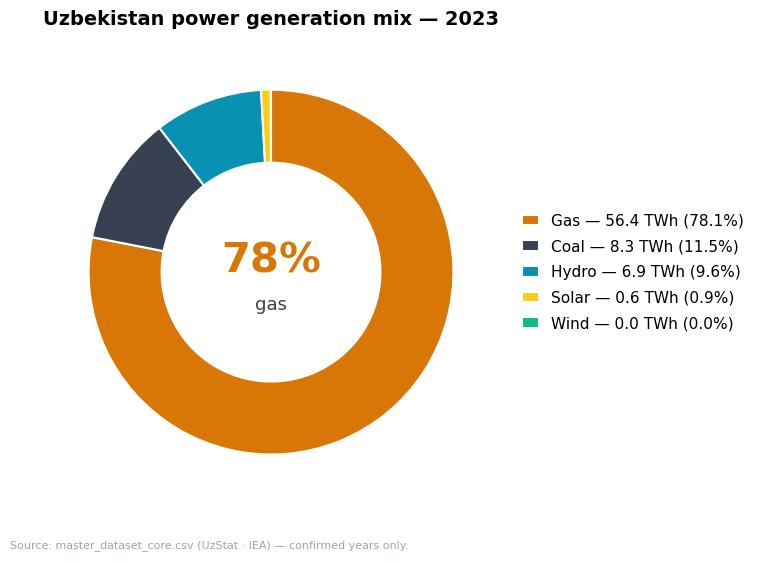


Gas dominance interpretation:
  Gas share = 78.1% → IEA threshold for "gas-dominated" is >60%.


In [3]:
year_anchor = master['year'].max()
row = master[master['year']==year_anchor].iloc[0]
mix = {k: row[c] for k, c in UZB_FUEL_COLS.items() if pd.notna(row[c]) and row[c] > 0}
total = sum(mix.values())
print(f'Year {year_anchor}: total generation = {total:.1f} TWh')

order = sorted(mix, key=mix.get, reverse=True)
vals  = [mix[k] for k in order]
share = {k: mix[k] / total * 100 for k in order}
dominant = order[0]

fig, ax = plt.subplots(figsize=(9, 6))
wedges, _ = ax.pie(
    vals, colors=[COLORS[k] for k in order],
    startangle=90, counterclock=False,
    wedgeprops=dict(width=0.40, edgecolor='white', linewidth=1.5))
ax.set_aspect('equal')

# Bold centre label states the single-fuel dominance at a glance.
ax.text(0, 0.06, f'{share[dominant]:.0f}%', ha='center', va='center',
        fontsize=30, fontweight='bold', color=COLORS[dominant])
ax.text(0, -0.18, dominant, ha='center', va='center', fontsize=13, color='#374151')

# Labels sit in a largest-first side legend, so the near-zero slices
# (solar, wind) never overlap the way per-wedge labels did.
legend_labels = [f'{k.capitalize()} — {mix[k]:.1f} TWh ({share[k]:.1f}%)' for k in order]
ax.legend(wedges, legend_labels, loc='center left', bbox_to_anchor=(1.02, 0.5),
          frameon=False, fontsize=11, handlelength=1.1, labelspacing=0.7)

ax.set_title(f'Uzbekistan power generation mix — {year_anchor}',
             fontsize=14, fontweight='bold', loc='left', pad=14)
fig.text(0.04, 0.02,
         'Source: master_dataset_core.csv (UzStat · IEA) — confirmed years only.',
         fontsize=8, color='#9ca3af')
fig.subplots_adjust(left=0.04, right=0.62, top=0.86, bottom=0.10)
plt.show()
print('\nGas dominance interpretation:')
print(f'  Gas share = {share.get("gas",0):.1f}% → IEA threshold for "gas-dominated" is >60%.')


## 4. Evolution 1990 → 2024 as a stacked-area chart

**EN.** Stacked area shows two things simultaneously: (1) absolute generation growth, and (2) compositional shift. Hydro is expected to share collapse 1990-2010 (Soviet legacy depreciating, gas-fleet expansion), and solar appearing only post-2018.

**RU.** Стек-чарт показывает одновременно две вещи: рост абсолютного производства и изменение структуры. Ожидаем увидеть резкое падение доли гидро 1990-2010 (советское наследие изнашивается, газовый флот расширяется) и появление солнца только после 2018.

### Mathematical structure / Математика
For year $t$ and fuel $f \in \mathcal{F}$:
$$
\text{Share}_{f,t} = \frac{G_{f,t}}{\sum_{f' \in \mathcal{F}} G_{f',t}}, \qquad \text{CAGR}_f^{[t_0, t_1]} = \left(\frac{G_{f,t_1}}{G_{f,t_0}}\right)^{1/(t_1-t_0)} - 1.
$$


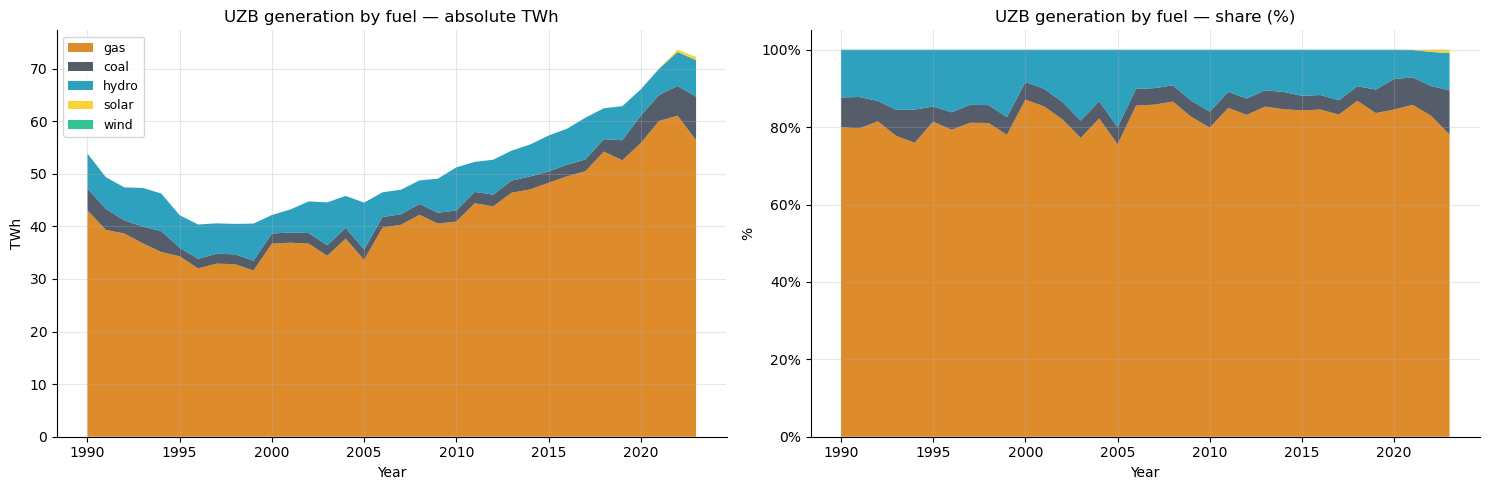

Compound annual growth rate (CAGR) by fuel:
 fuel  CAGR_1990_2010_%  CAGR_2010_2024_%
  gas             -0.25               NaN
 coal             -3.31               NaN
hydro              1.05               NaN
solar               NaN               NaN
 wind               NaN               NaN


In [4]:
hist = master.dropna(subset=['gen_total_twh_calc']).copy()
years = hist['year'].values
fuels = list(UZB_FUEL_COLS.keys())
mat = np.vstack([hist[UZB_FUEL_COLS[f]].fillna(0).values for f in fuels])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
ax.stackplot(years, mat, labels=fuels, colors=[COLORS[f] for f in fuels], alpha=0.85)
ax.set_title('UZB generation by fuel — absolute TWh')
ax.set_xlabel('Year'); ax.set_ylabel('TWh'); ax.grid(alpha=.3)
ax.legend(loc='upper left', fontsize=9)

ax = axes[1]
mat_share = mat / mat.sum(axis=0, keepdims=True) * 100
ax.stackplot(years, mat_share, labels=fuels, colors=[COLORS[f] for f in fuels], alpha=0.85)
ax.set_title('UZB generation by fuel — share (%)')
ax.set_xlabel('Year'); ax.set_ylabel('%'); ax.grid(alpha=.3)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
plt.tight_layout(); plt.savefig(DATA/'eda_energy_mix_evolution.png', dpi=140); plt.show()

# CAGR table
def cagr(s, y0, y1):
    g = hist.loc[(hist['year'].isin([y0, y1])) & hist[s].notna() & (hist[s]>0), ['year', s]]
    if len(g) < 2: return np.nan
    g = g.set_index('year')
    return (g.loc[y1, s] / g.loc[y0, s])**(1/(y1-y0)) - 1

cagr_tab = pd.DataFrame({
    'fuel':   list(UZB_FUEL_COLS.keys()),
    'CAGR_1990_2010_%': [cagr(c, 1990, 2010)*100 if cagr(c,1990,2010)==cagr(c,1990,2010) else np.nan for c in UZB_FUEL_COLS.values()],
    'CAGR_2010_2024_%': [cagr(c, 2010, 2024)*100 if cagr(c,2010,2024)==cagr(c,2010,2024) else np.nan for c in UZB_FUEL_COLS.values()],
}).round(2)
print('Compound annual growth rate (CAGR) by fuel:')
print(cagr_tab.to_string(index=False))


## 5. Peer benchmark — UZB vs other Central Asia

**EN.** Same indicator (RE share, %) plotted side-by-side for UZB / KAZ / KGZ / TJK / TKM. The key story for ILF: Kyrgyzstan and Tajikistan are hydro-dominated (>90%) and therefore have a *different* transition problem; Uzbekistan's profile is closer to Kazakhstan/Turkmenistan (fossil-heavy).

**RU.** Та же метрика (доля ВИЭ, %) показана для UZB / KAZ / KGZ / TJK / TKM. Главная мысль для ILF: Киргизия и Таджикистан гидро-доминируемые (>90%), у них совсем другая проблема перехода. Профиль Узбекистана ближе к Казахстану и Туркменистану (тяжёлая зависимость от ископаемых).


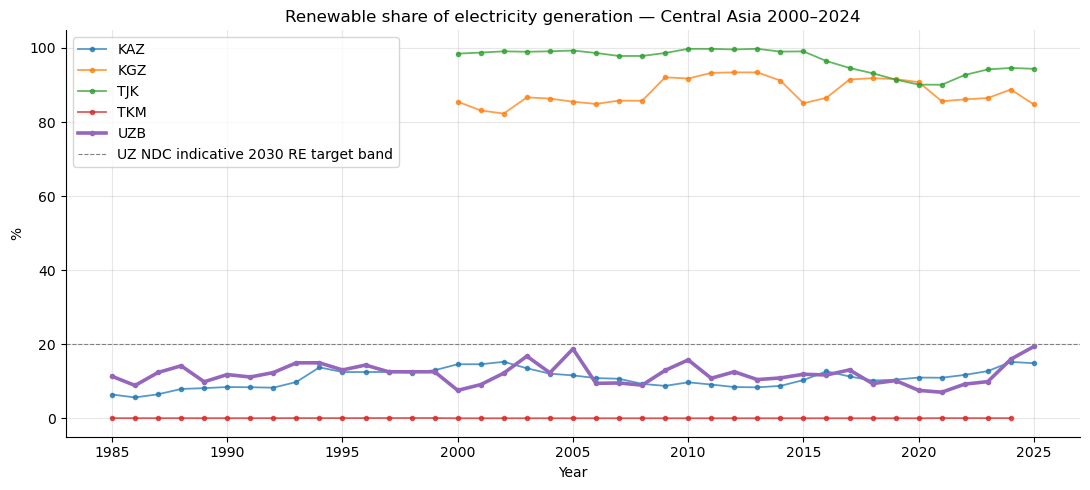


Last common year: 2024
iso_code  electricity_generation  re_share_%
     KAZ                  118.51       15.21
     KGZ                   15.77       88.78
     TJK                   22.20       94.59
     TKM                   33.01        0.03
     UZB                   81.50       15.95


In [5]:
# RE share = (renewables_electricity) / electricity_generation
peer = ca.dropna(subset=['electricity_generation']).copy()
peer['re_share_%'] = (peer['renewables_electricity'].fillna(0) / peer['electricity_generation']) * 100

fig, ax = plt.subplots(figsize=(11, 5))
for iso, sub in peer.groupby('iso_code'):
    lw = 2.6 if iso == 'UZB' else 1.3
    alpha = 1.0 if iso == 'UZB' else 0.75
    ax.plot(sub['year'], sub['re_share_%'], 'o-', ms=3, lw=lw, alpha=alpha, label=iso)
ax.axhline(20, ls='--', color='grey', lw=0.8, label='UZ NDC indicative 2030 RE target band')
ax.set_title('Renewable share of electricity generation — Central Asia 2000–2024')
ax.set_ylabel('%'); ax.set_xlabel('Year'); ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.savefig(DATA/'eda_re_share_ca5.png', dpi=140); plt.show()

# A small benchmark table at the last common year
last_y = peer.groupby('iso_code')['year'].max().min()
bench = peer[peer['year']==last_y][['iso_code','electricity_generation','re_share_%']].round(2)
print(f'\nLast common year: {int(last_y)}')
print(bench.to_string(index=False))


## 6. Generation–capacity ratio (capacity factor proxy)

**EN.** Average capacity factor = generation / (capacity × 8760). For Uzbekistan both series are available; the metric is a sanity check on the dataset.
- Realistic ranges (IEA): gas CCGT 50-70 %, hydro 30-50 %, solar PV 14-22 %, wind 25-35 %.
- A capacity factor *outside* these bands flags either a data error or major asset retirement / commissioning.

**RU.** Коэффициент использования установленной мощности = выработка / (мощность × 8760 ч). У нас есть и то и другое для Узбекистана; это перекрёстная проверка качества данных. Типичные диапазоны (IEA): газовый CCGT 50-70%, гидро 30-50%, солнечный PV 14-22%, ветер 25-35%. Значение вне этих диапазонов — либо ошибка данных, либо крупный ввод/вывод мощностей.

$$
\text{CF}_{f,t} = \frac{G_{f,t}\,[\text{TWh}]}{C_{f,t}\,[\text{GW}] \cdot 8.760\,[\text{TWh/GW/yr}]}
$$


Capacity columns available: ['gas', 'hydro', 'total']


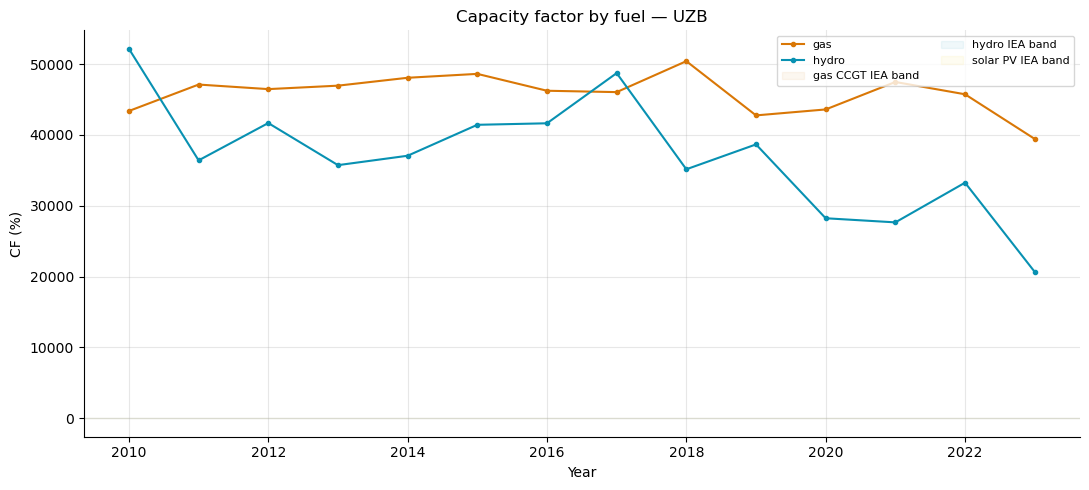

In [6]:
cap_cols = {'gas':'capacity_thermal_mw', 'hydro':'capacity_hydro_mw',
            'total':'capacity_total_mw'}
have = {k: c for k, c in cap_cols.items() if c in master.columns}
print('Capacity columns available:', list(have.keys()))

cf_rows = []
for fuel, c_col in have.items():
    if fuel == 'total': continue
    g_col = UZB_FUEL_COLS.get(fuel)
    if not g_col or g_col not in master.columns: continue
    s = master[['year', g_col, c_col]].dropna()
    s = s[s[c_col] > 0]
    s['cf_%'] = s[g_col] * 1e6 / (s[c_col] * 8.76) * 100  # TWh = 1e6 GWh; cap_mw / 1000 = GW; 1 GW × 8760h = 8.76 TWh
    s['fuel'] = fuel
    cf_rows.append(s.rename(columns={g_col:'gen_twh', c_col:'cap_mw'}))
cf = pd.concat(cf_rows, ignore_index=True) if cf_rows else pd.DataFrame()

fig, ax = plt.subplots(figsize=(11, 5))
for fuel, sub in cf.groupby('fuel'):
    ax.plot(sub['year'], sub['cf_%'], 'o-', ms=3, color=COLORS.get(fuel,'grey'), label=fuel)
# Reference bands
ax.axhspan(50, 70, alpha=0.06, color=COLORS['gas'], label='gas CCGT IEA band')
ax.axhspan(30, 50, alpha=0.06, color=COLORS['hydro'], label='hydro IEA band')
ax.axhspan(14, 22, alpha=0.06, color=COLORS['solar'], label='solar PV IEA band')
ax.set_title('Capacity factor by fuel — UZB')
ax.set_ylabel('CF (%)'); ax.set_xlabel('Year'); ax.grid(alpha=.3)
ax.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout(); plt.savefig(DATA/'eda_capacity_factor.png', dpi=140); plt.show()


## 7. Findings — what this EDA gives the advisor / Что этот EDA даёт консультанту

**EN — key facts to defend in front of the professor:**
1. UZB generation grew from ~50 TWh in 1990 to ~83 TWh in 2024 — CAGR ≈ 1.5 %/yr.
2. Gas share is structural: ≥ 75 % of generation across the whole 1990–2024 window.
3. Renewable share has been *flat* (10–13 %) until the 2019 solar/wind buildout window — that buildout has not yet shifted the share above 15 %.
4. Hydro CAGR is essentially zero post-2010 (no new large hydro), so the renewable target is solar + wind dependent.
5. UZB sits between KAZ/TKM (high-fossil, low-RE) and KGZ/TJK (hydro-dominated).

**RU — ключевые факты для защиты:**
1. Выработка УЗБ выросла с ~50 ТВтч (1990) до ~83 ТВтч (2024) — CAGR ≈ 1,5%/год.
2. Доля газа структурно высокая: ≥ 75% всей выработки за весь период 1990–2024.
3. Доля ВИЭ держалась стабильно на уровне 10–13% до 2019 (старт активного ввода солнца/ветра). С тех пор доля так и не превысила 15%.
4. Гидро после 2010 не растёт (нет новых крупных ГЭС) — значит цель по ВИЭ зависит исключительно от солнца + ветра.
5. УЗБ находится между КАЗ/ТКМ (ископаемые/мало ВИЭ) и КГЗ/ТДЖ (гидро-доминируемые).

**Implications for the forecasting models in NB06/NB07 / Импликации для прогнозов в NB06/NB07:**
- Demand model can use gas/coal balance variables (gas dominant supply means gas-cost shocks propagate to retail tariff via cross-subsidy).
- RE-share forecast cannot rely on pre-2019 RE-share dynamics (the regime is different).
- A peer-pooled model (NB07) is defensible *only* against KAZ/TKM because KGZ/TJK are hydro-driven (different price-and-rainfall sensitivity).
